# Document Scanning and Text Block Segmentation 📄

This project implements computer vision techniques to automatically detect document boundaries, correct perspective distortion, and segment text blocks from raw images.

**Main Pipeline:**
1. **Document Scanner (Perspective Transform):** Detects the document's contour and flattens it using a four-point perspective warp.
2. **Text Block Segmentation:** Uses adaptive thresholding and morphological operations (Dilation) to group adjacent characters into distinct text blocks or paragraphs.

In [1]:
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configure global Matplotlib display settings
plt.rcParams['figure.figsize'] = (10, 8)

def show_image(image, title="Image", figsize=(8, 6)):
    """
    Cross-platform image display utility using Matplotlib.
    Automatically handles both RGB (color) and Grayscale images.
    """
    plt.figure(figsize=figsize)
    if len(image.shape) == 3:
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

## 1. Document Scanner Utility Functions
Functions to order coordinate points and apply a perspective warp to simulate a top-down scanned view.

In [2]:
def order_points(pts):
    """Sorts 4 points in order: top-left, top-right, bottom-right, bottom-left"""
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # Top-left
    rect[2] = pts[np.argmax(s)]   # Bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)] # Top-right
    rect[3] = pts[np.argmax(diff)] # Bottom-left

    return rect

def four_point_transform(image, pts):
    """Applies a perspective transform to flatten the document"""
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Calculate width of the new image
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # Calculate height of the new image
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped

## 2. Document Processing & Text Block Detection Pipeline
Locates the document boundary, applies the warp, and isolates text blocks using morphological dilation.

In [3]:
def process_document(image_path):
    # --- STEP 1: LOAD & PREPROCESS ---
    image = cv2.imread(image_path)
    if image is None:
        print(f"Image not found at: {image_path}")
        return

    # Resize for faster processing while keeping the aspect ratio
    ratio = image.shape[0] / 500.0
    orig = image.copy()
    image_resized = cv2.resize(image, (int(image.shape[1] / ratio), 500))

    gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Edge Detection
    edged = cv2.Canny(gray, 75, 200)
    show_image(edged, title="1. Canny Edge Detection")

    # --- STEP 2: FIND DOCUMENT CONTOUR ---
    cnts = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]

    screenCnt = None
    for c in cnts:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)

        # If the contour has 4 points, we assume it's the document
        if len(approx) == 4:
            screenCnt = approx
            break

    if screenCnt is None:
        print("Document contour not clearly found. Using original image.")
        warped = orig
    else:
        # Scale the contour coordinates back to the original image size
        scaled_contour = (screenCnt * ratio).astype(int)

        # Draw contour on a copy of the original image
        debug_img_orig = orig.copy()
        cv2.drawContours(debug_img_orig, [scaled_contour], -1, (0, 255, 0), 5)
        show_image(debug_img_orig, title="2. Document Outline Detected")

        # Apply perspective transform
        warped = four_point_transform(orig, screenCnt.reshape(4, 2) * ratio)
        show_image(warped, title="3. Perspective Warp Applied")

    # --- STEP 3: ADAPTIVE BINARIZATION ---
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(warped_gray, (3, 3), 0)
    show_image(blurred, title="4. Blurred Grayscale")

    binary_1 = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, # Use INV to make text white, background black
        31,
        10
    )
    binary = cv2.GaussianBlur(binary_1, (5, 5), 0)
    show_image(binary, title="5. Adaptive Binarization")

    # --- STEP 4: MORPHOLOGY & NOISE REMOVAL ---
    # Create horizontal rectangular kernel to connect characters into blocks
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))

    # Remove artificial borders/margins caused by scanning
    margin = 25
    h, w = binary.shape
    binary[0:margin, :] = 0           # Clear top margin
    binary[h-margin:h, :] = 0         # Clear bottom margin
    binary[:, 0:margin] = 0           # Clear left margin
    binary[:, w-margin:w] = 0         # Clear right margin

    # Dilation to merge text regions
    dilated = cv2.dilate(binary, kernel, iterations=1)
    show_image(dilated, title="6. Morphological Dilation (Text Blocks)")

    # --- STEP 5: EXTRACT TEXT BLOCKS ---
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output_image = warped.copy()

    min_area = 500 # Minimum area threshold

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)
        if area > min_area:
            # Draw green bounding boxes around text areas
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    show_image(output_image, title="7. Final Text Block Segmentation", figsize=(10, 8))

## 3. Run Pipeline

In [4]:
# 1. Define the directory for images
image_dir = 'images'

# 2. Automatically download a sample image if it doesn't exist
# (It ensures the Notebook runs smoothly even if the user hasn't downloaded the repo)
sample_filename = 'image_1.jpg'
sample_path = os.path.join(image_dir, sample_filename)

if not os.path.exists(sample_path):
    print(f"Sample image not found at '{sample_path}'. Attempting to download...")
    os.makedirs(image_dir, exist_ok=True)

    # Replace this URL with the raw link to image on Github
    sample_url = 'https://raw.githubusercontent.com/kietnguyen-0902/Document-Scanner-OpenCV/refs/heads/main/images/image_1.jpg'

    try:
        urllib.request.urlretrieve(sample_url, sample_path)
        print("Download successful!")
    except Exception as e:
        print(f"Failed to download image. Error: {e}")
        print("Please upload the image manually or check the URL.")

# 3. List all available images in the directory for easy reference
if os.path.exists(image_dir):
    # Filter only image files to avoid clutter
    available_images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Available images in '{image_dir}': {available_images}")

Available images in 'images': ['image_1.jpg', 'image_2.jpg']


Starting Document Processing Pipeline...


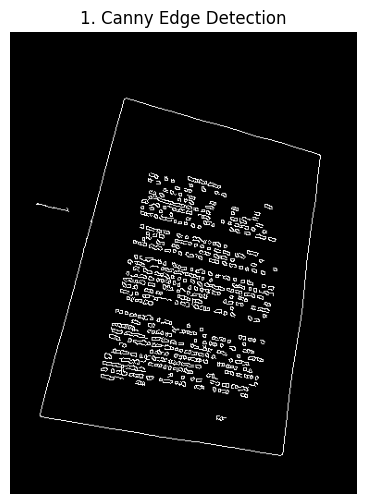

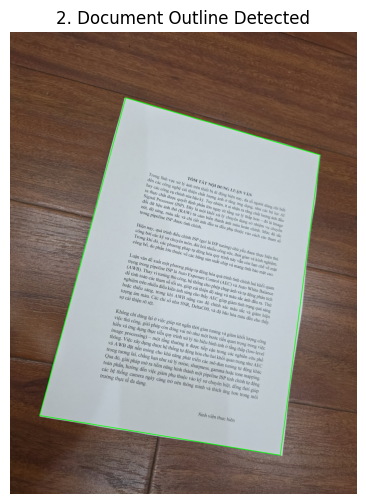

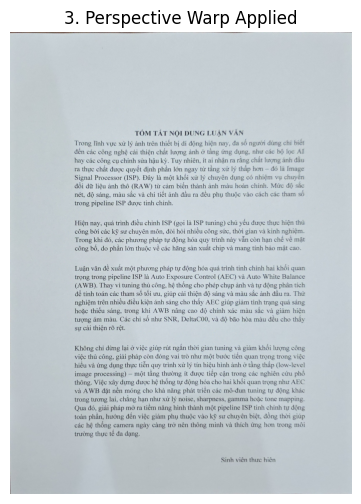

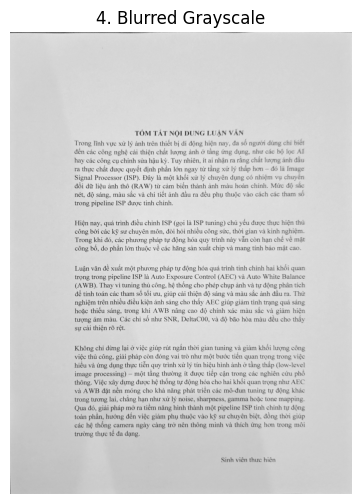

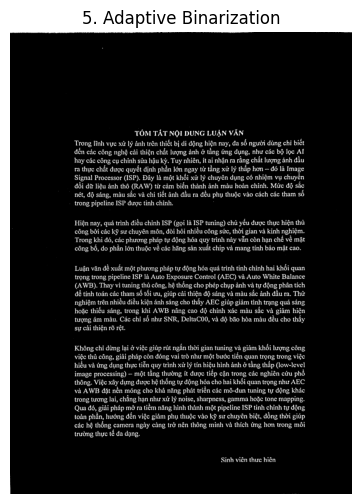

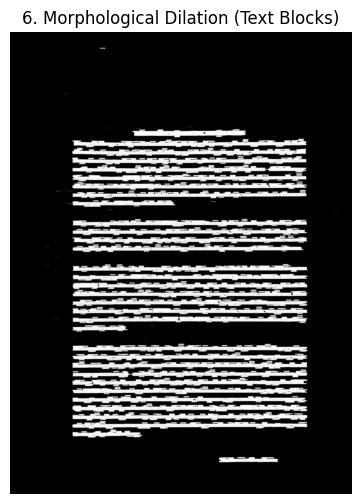

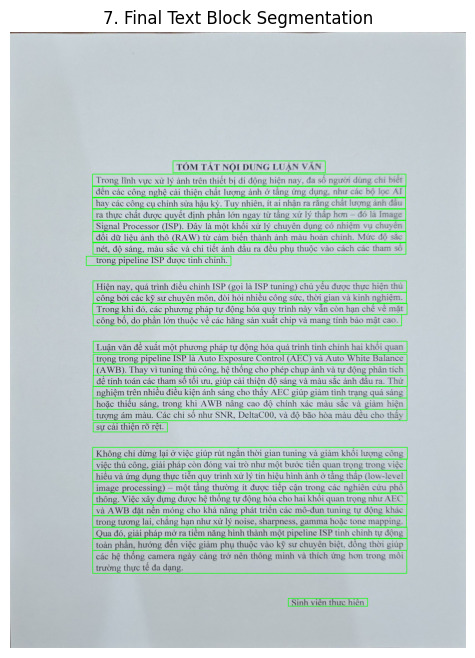

In [5]:
# 1. SELECT THE IMAGE TO PROCESS
# Change this variable to test with other images in the folder
selected_filename = 'image_1.jpg'
image_path = os.path.join(image_dir, selected_filename)

# 2. Run the processing pipeline
print("Starting Document Processing Pipeline...")
process_document(image_path)